# Adaptive Nonlinear Vector Autoregression: Robust Forecasting for Noisy Chaotic Time Series
## Author
- **Name**: Azimov Sherkhon Azizkhon Ugli
- **Email**: sherxonazimov94@pusan.ac.kr
- **GitHub**: @AzimovSherkhon

Method: **Adaptive Nonlinear Vector Autoregression** 

Code: Prediction on unseen test data

Best Config Found: \
k=10, hidden_dim=1000, Adam LR=1e-05

In [1]:
# ============================================================
# Imports & Setup
# ============================================================
import torch
import warnings
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Torch defaults
torch.set_default_dtype(torch.float32)

# ----------------------------
# Device setup (choose GPU 0)
# ----------------------------
if torch.cuda.is_available():
    torch.cuda.set_device(0)   # pick GPU 0
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print(f"Device in use: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.current_device()} - {torch.cuda.get_device_name(device)}")

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)


Device in use: cuda:0
CUDA device: 0 - A100-PCIE-40GB


(500000, 100)


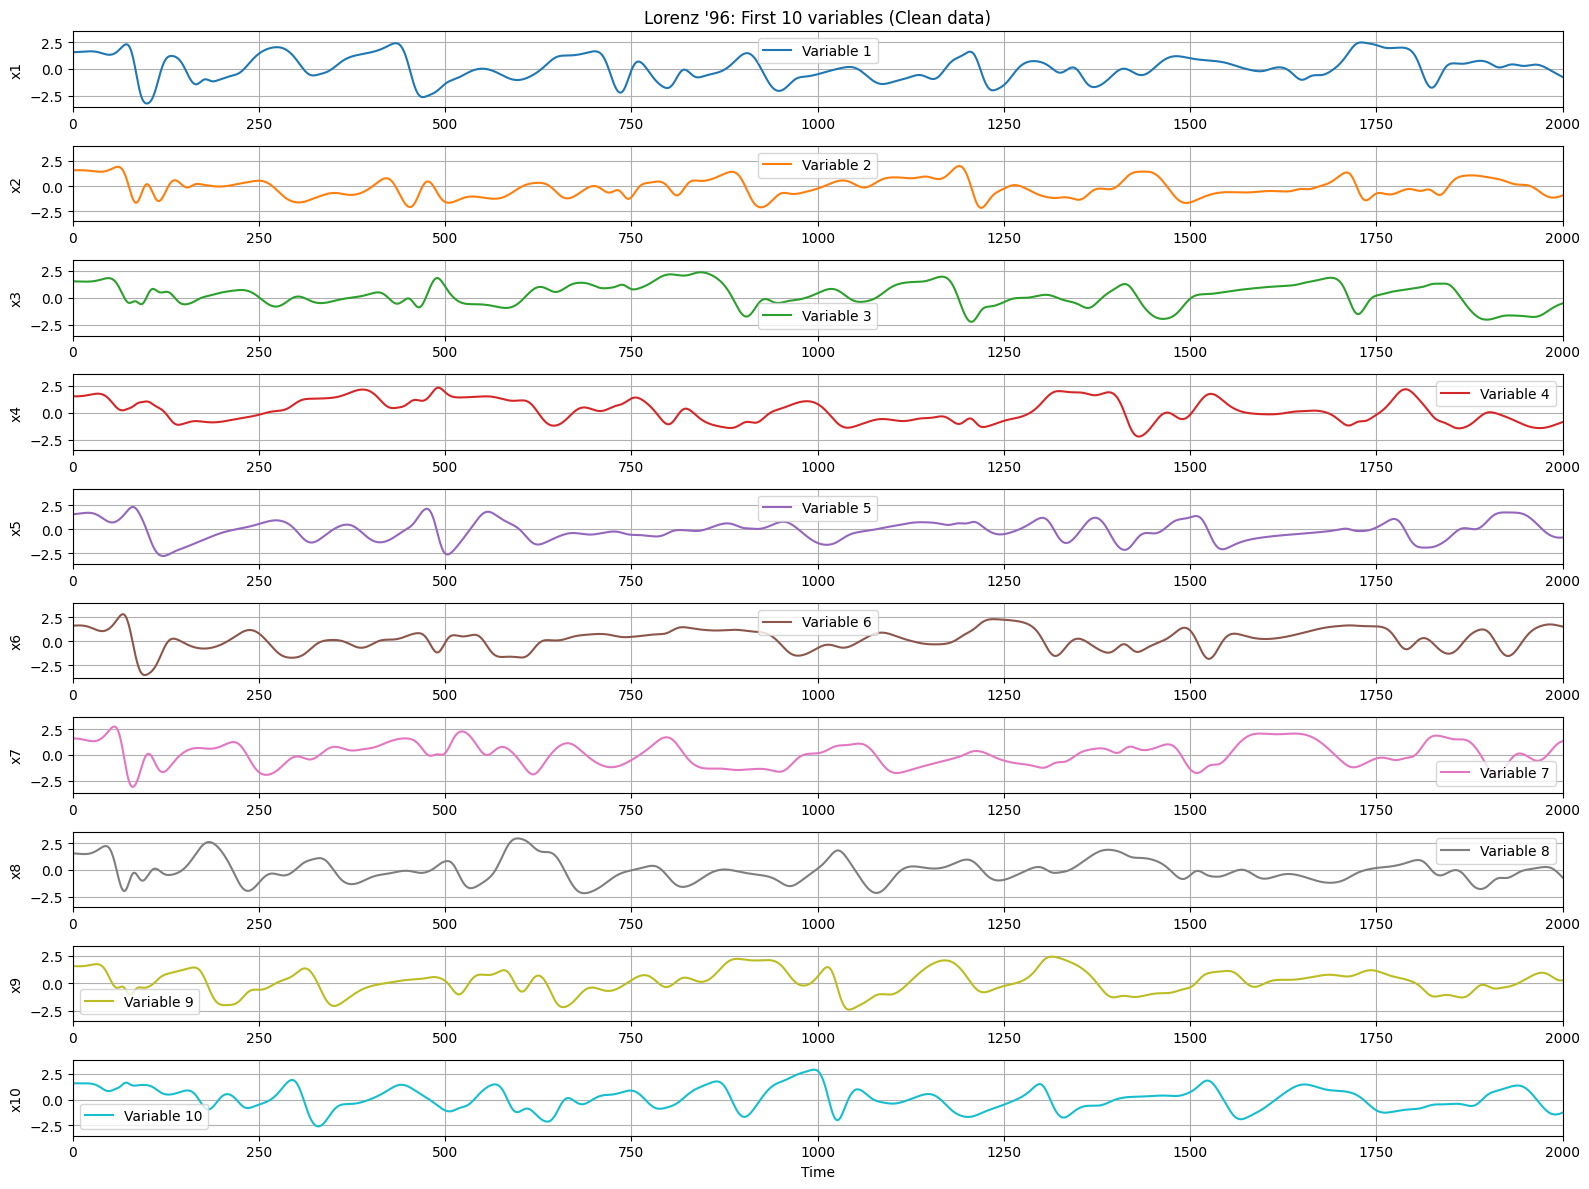

In [2]:
# ============================================================
# Load Lorenz 96 Clean Data
# ============================================================
data = np.load("lorenz96_100_noise_0.npy", allow_pickle=True).item()
l96_data = data["data"]   # (100, 1000001)
meta = data["meta"]   # dict with warmup/train/val/test/mean/std
l96 = l96_data.T
print(l96.shape)

# ============================================================
# Visualization: First 10 Variables of Lorenz '96
# ============================================================
plt.figure(figsize=(16, 12))
num_vars_to_plot = 10
time = np.arange(l96.shape[0])

for i in range(num_vars_to_plot):
    plt.subplot(num_vars_to_plot, 1, i + 1)
    plt.plot(time, l96[:, i], label=f'Variable {i+1}', color=f'C{i % 10}')
    plt.ylabel(f'x{i+1}')
    plt.grid(True)
    if i == 0:
        plt.title("Lorenz '96: First 10 variables (Clean data)")
    if i == num_vars_to_plot - 1:
        plt.xlabel('Time')
    plt.legend()
    plt.xlim(0, 2000)  

plt.tight_layout()
plt.show()

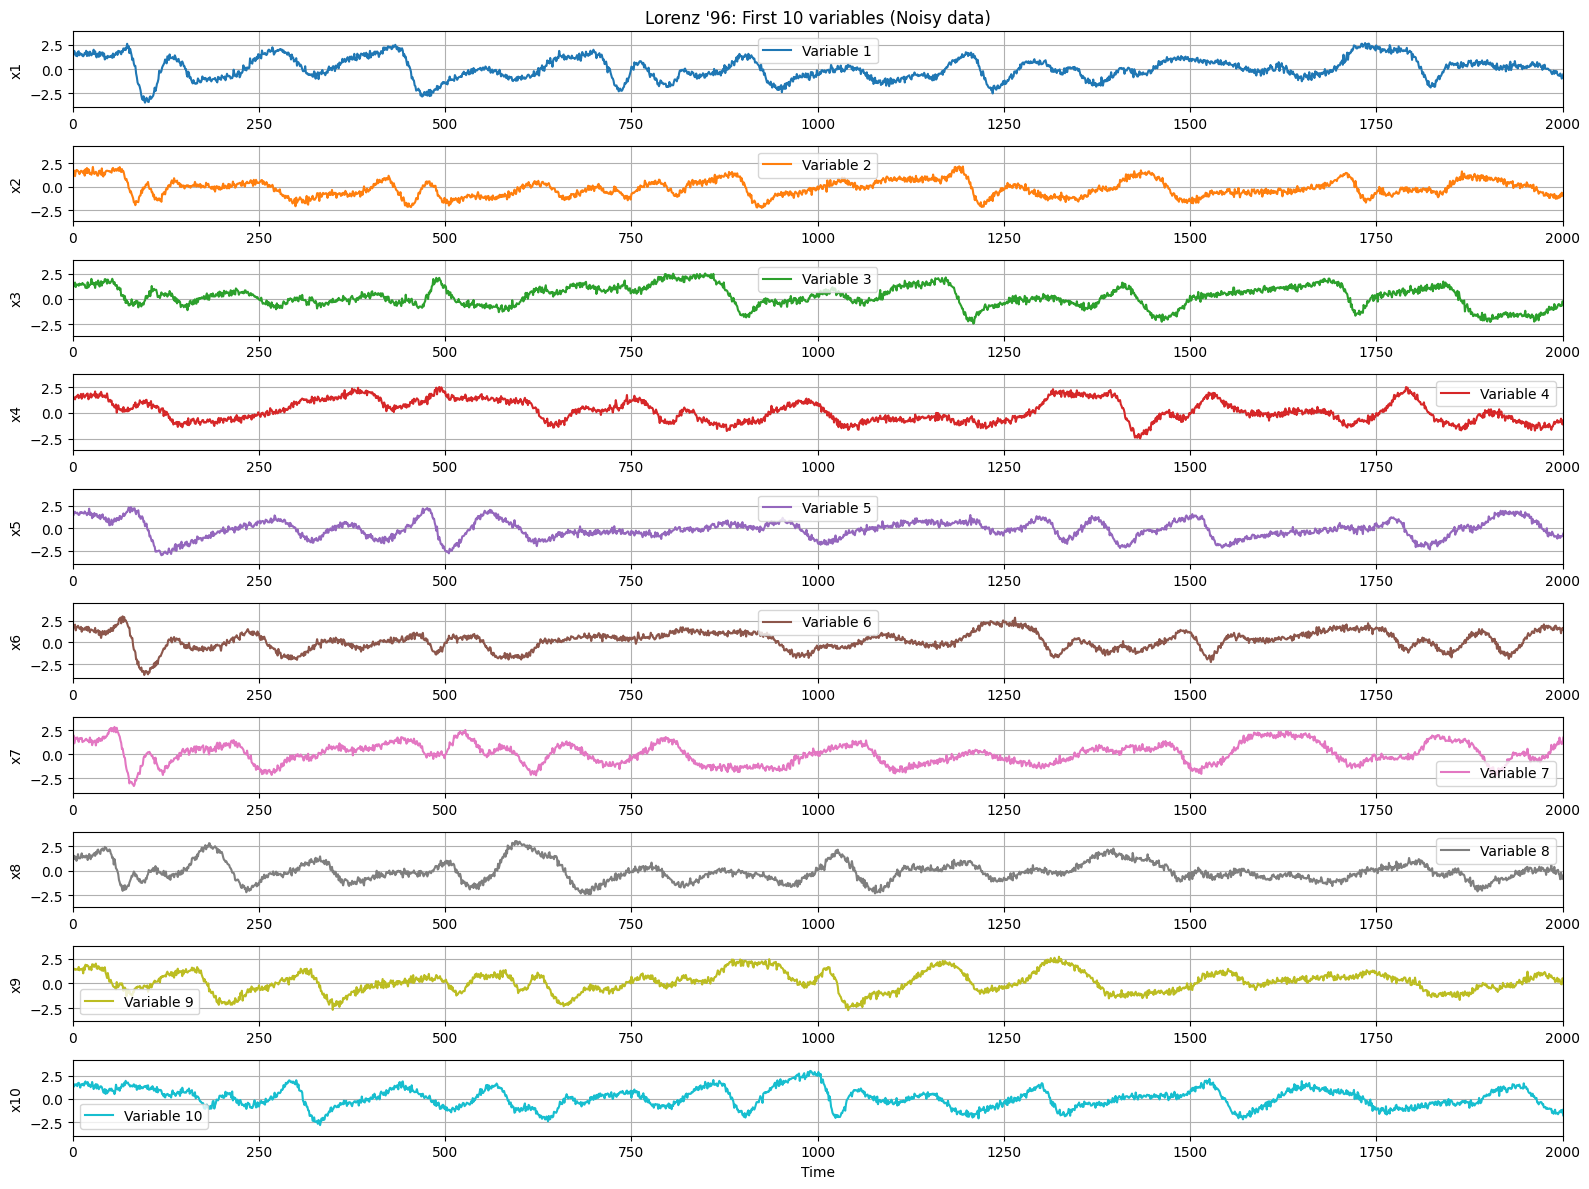

In [3]:
# ============================================================
# Reproducibility
# ============================================================
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# # Load Lorenz 63 Noisy Data
# ============================================================
# Measurement noise (applied globally to dataset)
dataset_noise_scale = 0.20
data_noisy = np.load("lorenz96_100_noise_20.npy", allow_pickle=True).item()
X_noisy_dataset = data_noisy["data"]   # (3, 5001)
meta_noise = data_noisy["meta"]   # dict with warmup/train/val/test/mean/std
X_noisy_dataset = X_noisy_dataset.T

# ============================================================
# Visualization: First 10 Variables of Lorenz '96
# ============================================================
plt.figure(figsize=(16, 12))
num_vars_to_plot = 10
time = np.arange(l96.shape[0])

for i in range(num_vars_to_plot):
    plt.subplot(num_vars_to_plot, 1, i + 1)
    plt.plot(time, X_noisy_dataset[:, i], label=f'Variable {i+1}', color=f'C{i % 10}')
    plt.ylabel(f'x{i+1}')
    plt.grid(True)
    if i == 0:
        plt.title("Lorenz '96: First 10 variables (Noisy data)")
    if i == num_vars_to_plot - 1:
        plt.xlabel('Time')
    plt.legend()
    plt.xlim(0, 2000)  

plt.tight_layout()
plt.show()

X = torch.tensor(X_noisy_dataset, dtype=torch.float32)  # noisy input
X_true = torch.tensor(l96, dtype=torch.float32)          # clean reference

# Dataset splits
warmup_len, train_len, val_len, test_len = 1000, 399000, 50000, 50000

X_warmup = X[:warmup_len].to(device)
X_train_clean = X[warmup_len:warmup_len + train_len]
X_val  = X[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test = X[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Ground truth references
X_val_true  = X_true[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test_true = X_true[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Training-time noise (works as a regularization only during training)
train_noise_scale = 0.0  # We only add it for noise free-case
signal_std = X_train_clean.std(dim=0, keepdim=True).cpu().numpy()
train_noise = np.random.normal(0.0, train_noise_scale * signal_std, X_train_clean.shape)
X_train = torch.tensor((X_train_clean.cpu().numpy() + train_noise).astype(np.float32), device=device)

In [4]:
# ============================================================
# Adaptive NVAR Model
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class AdaptiveNVARModel(nn.Module):
    def __init__(self, dk, m, d, hidden_dim):
        super().__init__()
        self.mlp = FeatureMLP(dk, hidden_dim, m)
        self.readout = nn.Linear(dk + m, d, bias=False)

    def forward(self, H_lin):
        H_nn = self.mlp(H_lin)
        H_total = torch.cat([H_lin, H_nn], dim=1)
        return self.readout(H_total)


# ============================================================
# Helper Functions
# ============================================================
def construct_H_lin(X, k):
    """Constructs delay-embedded features from time series."""
    T = X.shape[0]
    return torch.cat([X[i:T - k + i] for i in range(k)], dim=1)


def init_weights_stable(m):
    """Stable Xavier initialization for linear layers."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
        with torch.no_grad():
            m.weight.mul_(1.0)


# ============================================================
# Training Function (Adam only)
# ============================================================
def train_model_adam_only(
    X, k, m, hidden_dim=200, num_epochs_adam=1000, batch_size=1024,
    save_path="best_joint_model_0percent_noise.pth",
    patience=100, tolerance=1e-8, lr=1e-5, use_amp=False
):
    X = X.to(device)
    H_lin = construct_H_lin(X, k)                 # [n, dk]
    Y = X[k:] - X[k - 1:-1]                       # [n, d]
    n, dk = H_lin.shape
    d = Y.shape[1]

    # Dataset + Dataloader
    dataset = TensorDataset(H_lin, Y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Model: pass hidden_dim
    model = AdaptiveNVARModel(dk=dk, m=m, d=d, hidden_dim=hidden_dim).to(device)
#    # Freeze MLP parameters if needed
#    for param in model.mlp.parameters():
#        param.requires_grad = False

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0
    )

    # Scheduler (reduces lr when loss plateaus)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=100
    )

    # AMP scaler
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    adam_losses = []
    best_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs_adam):
        model.train()
        epoch_loss = 0.0

        for H_batch, Y_batch in dataloader:
            H_batch = H_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()

            # Mixed precision forward & backward
            with torch.cuda.amp.autocast(enabled=use_amp):
                Y_hat = model(H_batch)
                loss = F.mse_loss(Y_hat, Y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item() * H_batch.size(0)

        current_loss = epoch_loss / n
        adam_losses.append(current_loss)

        # Step scheduler
        scheduler.step(current_loss)

        if epoch % 10 == 0 or epoch == num_epochs_adam - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"[Adam] Epoch {epoch:5d} | Loss: {current_loss:.4e} | LR: {current_lr:.2e}")

        # Early stopping
        if best_loss - current_loss > tolerance:
            best_loss = current_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    # Save best model
    if best_model_state is not None:
        torch.save(best_model_state, save_path)
        print(f"Best model saved with loss {best_loss:.4e} at epoch {epoch - epochs_no_improve}")
    else:
        torch.save(model.state_dict(), save_path)
        print("Model saved (no improvement detected).")

    return model


In [5]:
# ============================================================ 
# Prediction on Test Data (Adam only)
# ============================================================
k_grid = [10]
hidden_dim_grid = [1000]
adam_lr_grid = [1e-5]
batch_size_grid = [1024]

horizons = [25, 50, 75, 100]

base_seed, num_runs, num_windows = 2025, 5, int(test_len / 100)
d = 100
best_config, best_rmse, all_results = None, float("inf"), []

print("Starting Test Evaluation (Adam only)...\n")

for k in k_grid:
    dk = d * k
    m = int(10 * dk)

    for hidden_dim in hidden_dim_grid:
        for lr_adam in adam_lr_grid:
            for batch_size in batch_size_grid:

                all_run_rmses = {h: [] for h in horizons}

                for run in range(num_runs):
                    seed = base_seed + run
                    torch.manual_seed(seed)
                    torch.cuda.manual_seed_all(seed)
                    torch.backends.cudnn.deterministic = True
                    torch.backends.cudnn.benchmark = False

                    model_path = f"model_k{k}_m{m}_hd{hidden_dim}_adam{lr_adam}_bs{batch_size}.pth"

                    # Load or train model
                    model = train_model_adam_only(
                        X_train, k=k, m=m, hidden_dim=hidden_dim,
                        num_epochs_adam=20000,
                        batch_size=batch_size,
                        lr=lr_adam,
                        save_path=model_path
                    )
                    model.eval()

                    window_size = len(X_test_true) // num_windows
                    horizon_rmses = {h: [] for h in horizons}

                    for w in range(num_windows):
                        start, end = w * window_size, (w + 1) * window_size
                        X_test_true_window = X_test_true[start:end]

                        # Initialization: last k points before this test window
                        init_start = warmup_len + train_len + val_len + start - k
                        init_end   = warmup_len + train_len + val_len + start
                        X_init = X[init_start:init_end].to(device)

                        x_t = [x.clone() for x in X_init.unbind(0)]
                        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

                        predictions = []
                        for _ in range(window_size):
                            with torch.no_grad():
                                delta_x = model(H_lin)
                            x_next = x_t[-1] + delta_x.squeeze(0)
                            predictions.append(x_next)
                            x_t = x_t[1:] + [x_next]
                            H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

                        predictions_np = torch.stack(predictions).cpu().numpy()
                        y_true_np = X_test_true_window.cpu().numpy()

                        for h in horizons:
                            if h <= window_size:
                                rmse = np.sqrt(np.mean((y_true_np[:h] - predictions_np[:h]) ** 2))
                                horizon_rmses[h].append(rmse)

                    # Average RMSEs for this run
                    for h in horizons:
                        avg_rmse = np.mean(horizon_rmses[h])
                        all_run_rmses[h].append(avg_rmse)

                # Average over runs
                avg_rmse_horizons = {h: np.mean(all_run_rmses[h]) for h in horizons}
                std_rmse_horizons = {h: np.std(all_run_rmses[h]) for h in horizons}

                print(f"[Test Evaluation] k={k}, hd={hidden_dim}, Adam LR={lr_adam}, BS={batch_size} → " +
                      ", ".join([f"h={h}: {avg_rmse_horizons[h]:.6f} ± {std_rmse_horizons[h]:.6f}"
                                 for h in horizons]))

                all_results.append((k, m, hidden_dim, lr_adam, batch_size, avg_rmse_horizons))

                # Track best result (e.g., horizon=100)
                if avg_rmse_horizons[100] < best_rmse:
                    best_rmse = avg_rmse_horizons[100]
                    best_config = (k, m, hidden_dim, lr_adam, batch_size)

# ============================================================
# Final Best Results
# ============================================================
print("\n=== Final Results Summary ===")
print(f"Optimal config used: k={best_config[0]}, m={best_config[1]}, hd={best_config[2]}, "
      f"lr={best_config[3]}, bs={best_config[4]}")


Starting Test Evaluation (Adam only)...

[Adam] Epoch     0 | Loss: 8.4330e-02 | LR: 1.00e-05
[Adam] Epoch    10 | Loss: 5.7729e-02 | LR: 1.00e-05
[Adam] Epoch    20 | Loss: 5.4731e-02 | LR: 1.00e-05
[Adam] Epoch    30 | Loss: 5.4285e-02 | LR: 1.00e-05
[Adam] Epoch    40 | Loss: 5.4150e-02 | LR: 1.00e-05
[Adam] Epoch    50 | Loss: 5.4084e-02 | LR: 1.00e-05
[Adam] Epoch    60 | Loss: 5.4044e-02 | LR: 1.00e-05
[Adam] Epoch    70 | Loss: 5.4016e-02 | LR: 1.00e-05
[Adam] Epoch    80 | Loss: 5.3994e-02 | LR: 1.00e-05
[Adam] Epoch    90 | Loss: 5.3976e-02 | LR: 1.00e-05
[Adam] Epoch   100 | Loss: 5.3960e-02 | LR: 1.00e-05
[Adam] Epoch   110 | Loss: 5.3946e-02 | LR: 1.00e-05
[Adam] Epoch   120 | Loss: 5.3934e-02 | LR: 1.00e-05
[Adam] Epoch   130 | Loss: 5.3922e-02 | LR: 1.00e-05
[Adam] Epoch   140 | Loss: 5.3910e-02 | LR: 1.00e-05
[Adam] Epoch   150 | Loss: 5.3899e-02 | LR: 1.00e-05
[Adam] Epoch   160 | Loss: 5.3888e-02 | LR: 1.00e-05
[Adam] Epoch   170 | Loss: 5.3877e-02 | LR: 1.00e-05
[Adam

In [6]:
# ============================================================
# Reload Fixed Best Model (Manual Parameters)
# ============================================================
model_path = model_path = f"model_k{k}_m{m}_hd{hidden_dim}_adam{lr_adam}_bs{batch_size}.pth"
best_model = AdaptiveNVARModel(dk=dk, m=m, d=d, hidden_dim=hidden_dim).to(device)
best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model.eval()

all_preds, all_true, all_noisy = [], [], []

# ------------------------------------------------------------
# Rollout predictions across windows
# ------------------------------------------------------------
for w in range(num_windows):
    start, end = w * window_size, (w + 1) * window_size
    X_test_true_window = X_test_true[start:end]
    X_test_noisy_window = X_test[start:end]

    # Initialization with last k noisy points
    init_start = warmup_len + train_len + val_len + start - k
    init_end   = warmup_len + train_len + val_len + start
    X_init = X[init_start:init_end].to(device)

    x_t = [x.clone() for x in X_init.unbind(0)]
    H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    predictions = []
    for _ in range(window_size):
        with torch.no_grad():
            delta_x = best_model(H_lin)
        x_next = x_t[-1] + delta_x.squeeze(0)
        predictions.append(x_next)

        # Update autoregressive state
        x_t = x_t[1:] + [x_next]
        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    all_preds.append(torch.stack(predictions).cpu().numpy())
    all_true.append(X_test_true_window.cpu().numpy())
    all_noisy.append(X_test_noisy_window.cpu().numpy())

# ------------------------------------------------------------
# Concatenate results
# ------------------------------------------------------------
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)
y_noisy = np.concatenate(all_noisy)

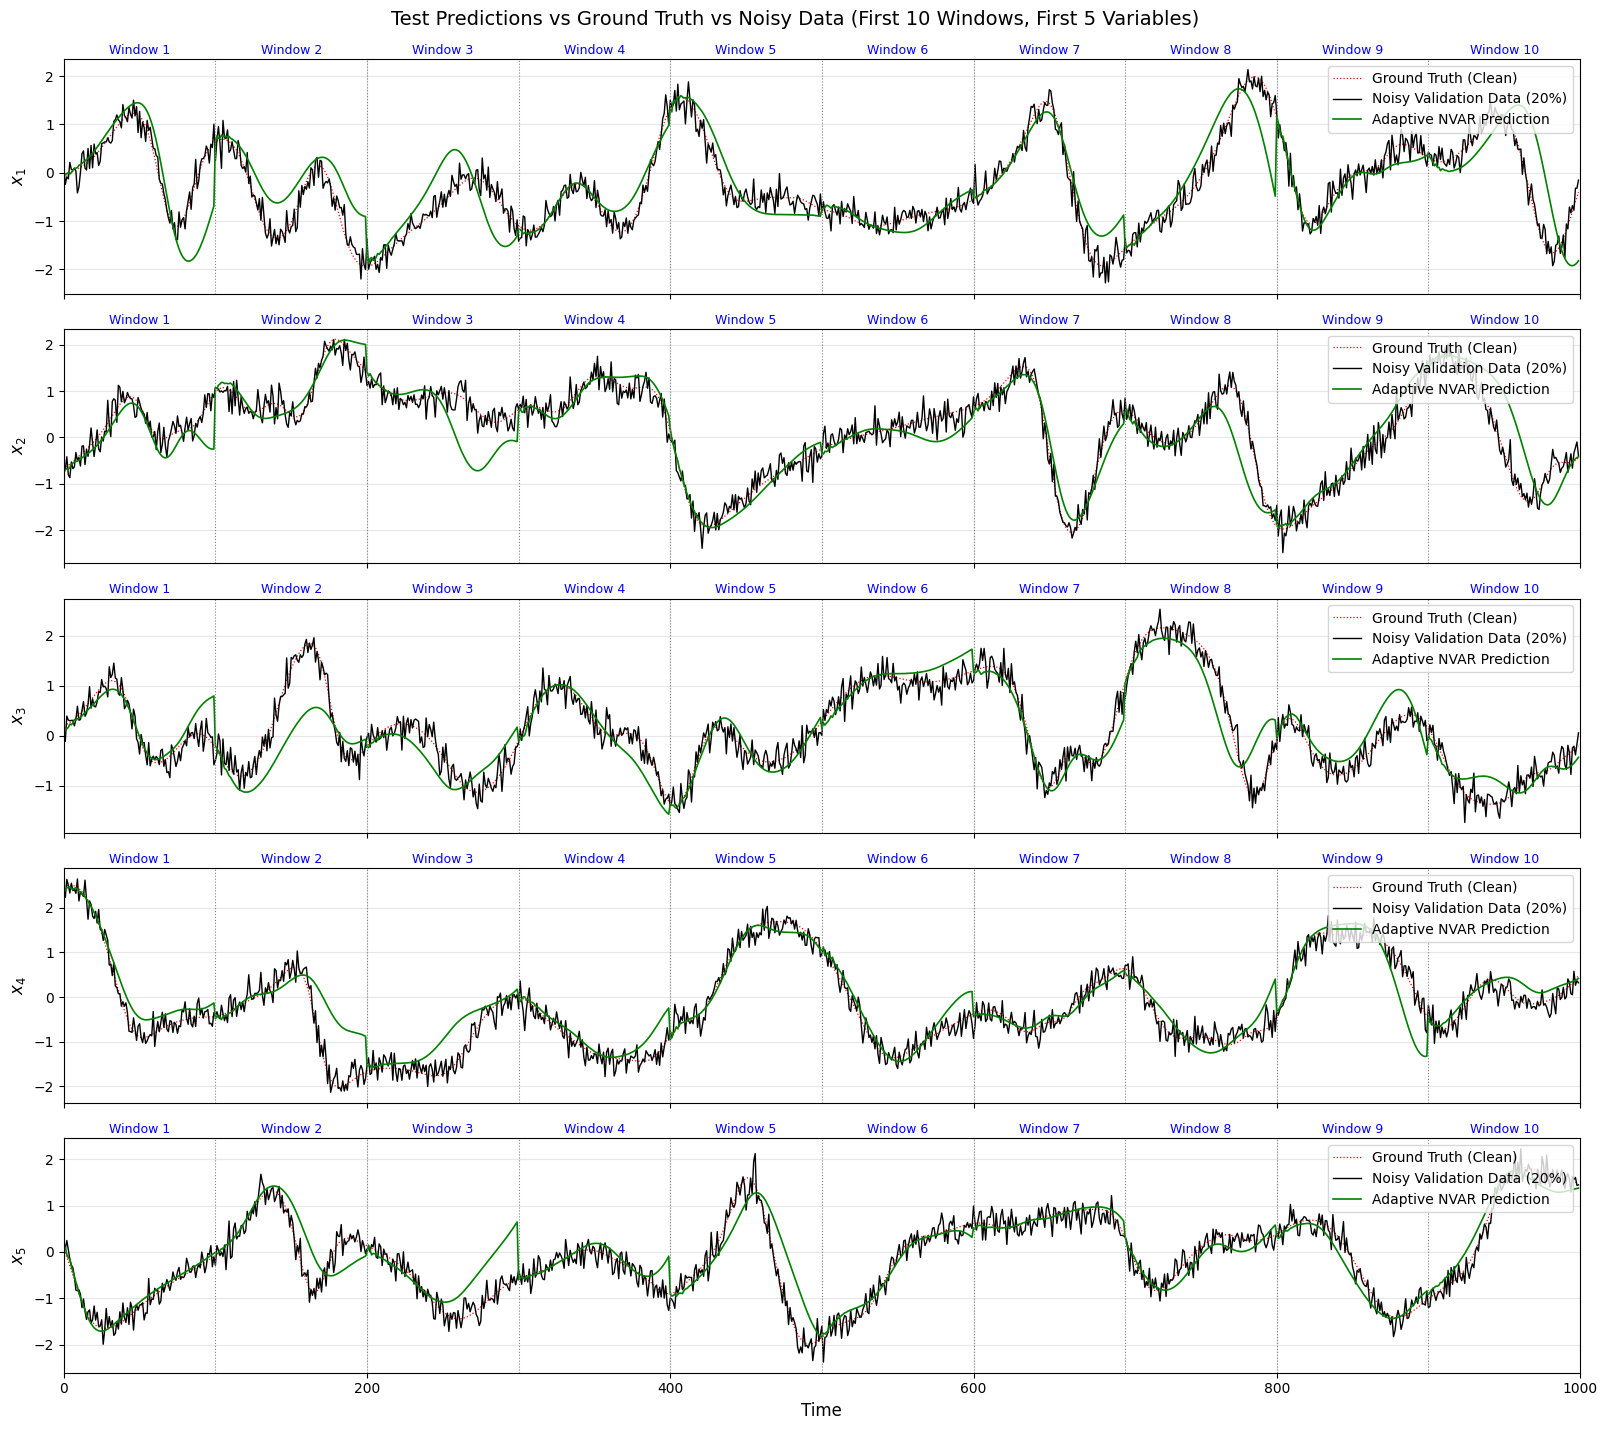

Saved plot as: Test_pred_vs_truth_k10_hd[1000]_noise0.20_first10_vars5.png


In [7]:
# ============================================================
# Visualization (per variable) - First 10 windows, subset of variables
# ============================================================

max_windows_to_plot = min(10, num_windows)  # plot at most 10 windows
end_idx = max_windows_to_plot * window_size

# Slice arrays to avoid oversized figure rendering
y_true_plot = y_true[:end_idx]
y_noisy_plot = y_noisy[:end_idx]
y_pred_plot = y_pred[:end_idx]

# Limit to first 5 variables for readability
max_vars_to_plot = min(5, y_true.shape[1])
variables = [f"x_{i+1}" for i in range(max_vars_to_plot)]

fig, axes = plt.subplots(max_vars_to_plot, 1, figsize=(16, 3 * max_vars_to_plot), sharex=True)

if max_vars_to_plot == 1:
    axes = [axes]  # make iterable

for i, ax in enumerate(axes):
    # Ground truth
    ax.plot(y_true_plot[:, i], label="Ground Truth (Clean)", color="red", linestyle=":", linewidth=0.9)

    # Noisy observations
    ax.plot(y_noisy_plot[:, i], label=f"Noisy Validation Data ({dataset_noise_scale*100:.0f}%)",
            color="black", linewidth=1.0, alpha=1.0)

    # Predictions
    ax.plot(y_pred_plot[:, i], label="Adaptive NVAR Prediction", color="green", linewidth=1.2)

    # Mark window boundaries
    for w in range(1, max_windows_to_plot):
        ax.axvline(w * window_size, color="gray", linestyle="dotted", linewidth=0.8)

    # Label windows at the center
    ylim = ax.get_ylim()
    for w in range(max_windows_to_plot):
        center = w * window_size + window_size // 2
        ax.text(center, ylim[1] * 1.02, f"Window {w+1}",
                ha="center", va="bottom", fontsize=9, color="blue")

    ax.set_ylabel(f"$x_{{{i+1}}}$", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time", fontsize=12)
fig.suptitle("Test Predictions vs Ground Truth vs Noisy Data (First 10 Windows, First 5 Variables)", fontsize=14, y=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.xlim(0, end_idx)

# Save and show
filename = f"Test_pred_vs_truth_k{k}_hd{hidden_dim_grid}_noise{dataset_noise_scale:.2f}_first10_vars5.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot as: {filename}")
